In [1]:
from collections import defaultdict
from typing import Iterable, Tuple

import numpy as np
import pandas as pd
from scipy.stats import beta, binom, t
import torch
from tqdm import tqdm

from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import KFold

from sklearn.utils.validation import check_is_fitted

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import (
    BaseEstimator,
    TransformerMixin,
    ClassifierMixin,
    RegressorMixin,
)
from sklearn.compose import ColumnTransformer


In [2]:

def performance_diff_test(
    mode, model_1, model_2, X, y, K=10, conf_level=0.95, seed=131125
) -> Tuple[float, float, float]:
    """
    When mode=regression: Performs a paired t-test to assess whether the difference in performance between two regression models is significant.
    When mode=classification: Performs McNemar's test to assess whether the difference in performance between two classification models is significant.

    Parameters:
    - mode: Specifies the model types, either regression or classification.
    - model_1: The first model to be compared.
    - model_2: The second model to be compared.
    - X: Features to be used as input to the models.
    - y: Labels to be used as input to the models.
    - K: K used for K-fold cross-validation.
    - conf_level: Confidence level for confidence interval.

    Returns:
    - p_val: The p-value associated with the null hypothesis stating that there is no difference in performance between model_1 and model_2.
    - lower: The lower b ound of the confidence interval.
    - upper: The upper bound of the confidence interval.
    """
    assert mode in {
        "classification",
        "regression",
    }, f"mode must equal either 'classification' or 'regression', mode provided {mode}"

    # dictionary to contain results per fold
    fold_results = defaultdict(list)

    # initializing number of test objects
    n = 0

    # initializing folds for outer loop
    kfold_out = KFold(n_splits=K, shuffle=True, random_state=seed)

    for i, (train_idx, test_idx) in enumerate(kfold_out.split(X)):
        # define train and test set for fold
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx].values.ravel()

        # adding to the value of test objects
        n += len(y_test)

        # fit models   

        fitted_model_1 = model_1.fit(X_train, y_train)
        fitted_model_2 = model_2.fit(X_train, y_train)

        # get predictions
        pred_1 = fitted_model_1.predict(X_test)
        pred_2 = fitted_model_2.predict(X_test)

        # compute difference in squared error for regression or agreements/disagreements for classification
        if mode == "regression":
            # computing sum of difference in squared losses
            

            z_1 = (pred_1 - y_test)**2
            z_2 = (pred_2 - y_test)**2
            z_i = z_1 - z_2
            
            # adding result to fold_results
            for y_test_val, pred_1_val, pred_2_val, z_1_val, z_2_val, z_i_val in zip(y_test, pred_1,pred_2,z_1,z_2,z_i):
                fold_results["z"].append(z_i_val)
                print(f"y_true: {y_test_val}\t Pred_1: {pred_1_val}\t Pred_2: {pred_2_val}\t z_1: {z_1_val}\t z_2: {z_2_val}\tz_i: {z_i_val}")
        
        # adding fold number to fold_results
        fold_results["fold"].append(i)   # delete if not using this key

    return fold_results
    # compute p-value and confidence interval bounds
    alpha = 1 - conf_level
    
    if mode == "regression":
        # vector containing all z_i values
        z = fold_results["z"]

        # average z_i value (eq 11.52c in the ML book)
        z_hat = np.mean(z)
        print(f"{z_hat = }")

        # empirical standard deviation (eq 11.52c in the ML book)
        emp_var = (1 / n*(n-1)) * np.sum([(z_val - z_hat)**2 for z_val in z])
        print(f"{emp_var = }")
        print(f"{np.sqrt(emp_var) = }")
        # computing the p-value (eq 11.53 in the ML book)
        p_val = 2 * t.cdf(x=-abs(z_hat), df=n-1, loc=0, scale=np.sqrt(emp_var))
        print(f"{p_val = }")

        # computing the lower and upper bound for the confidence interval (eq 11.52a and 11.52b in the ML book)
        lower, upper = t.ppf(q=[alpha/2, 1-alpha/2], df=n-1, loc=z_hat, scale=np.sqrt(emp_var))
        print(f"{lower = }")
        print(f"{upper = }")

    return p_val, lower, upper




In [3]:
import pandas as pd
import sklearn.linear_model as lm
import numpy as np
from utils import BaselineRegressor, ANNRegressor, Preprocessor, BaselineClassifier, ANNClassifier

FEATURES_REGRESSION = ["sbp","tobacco","ldl","typea","alcohol","age","chd","famhist"]
OUTCOME_REGRESSION = ["obesity"]
FEATURES_CLASSIFICATION = [ "sbp", "tobacco", "ldl", "typea", "alcohol", "age", "obesity", "famhist"]
OUTCOME_CLASSIFICATION = ["chd"]

regression_results = pd.read_csv("tlcv_results/regression_results.csv")
classification_results = pd.read_csv("tlcv_results/classification_results.csv")
regression_results_grouped = regression_results.groupby(["model", "param_name"], dropna=False)["param_val"].agg(pd.Series.mode).to_frame().reset_index()
classification_results_grouped = classification_results.groupby(["model", "param_name"], dropna=False)["param_val"].agg(pd.Series.mode).to_frame().reset_index()

reg_ridge_lam_parameter = regression_results_grouped[(regression_results_grouped["model"] == "Ridge") & (regression_results_grouped["param_name"] == "lambda")]["param_val"].values[0]
if np.array(reg_ridge_lam_parameter).shape != ():
    reg_ridge_lam_parameter = reg_ridge_lam_parameter[0]
reg_ridge_lam_parameter = float(reg_ridge_lam_parameter)

reg_ann_h_parameter = int(regression_results_grouped[(regression_results_grouped["model"] == "ANNRegressor") & (regression_results_grouped["param_name"] == "h")]["param_val"].values[0])
if np.array(reg_ann_h_parameter).shape != ():
    reg_ann_h_parameter = int(reg_ann_h_parameter[0])

reg_cv_seed_used = int(regression_results["cv_seed_used"].drop_duplicates().values[0])



# regression models
base_reg = BaselineRegressor()
lin_reg = lm.Ridge(alpha=reg_ridge_lam_parameter)
ann_reg = ANNRegressor(hidden_dim=reg_ann_h_parameter, input_dim=len(FEATURES_REGRESSION), n_epochs=60000)


# loading the data
df = pd.read_csv("data/heartDisease.csv")


# preprocessing data for regression
PreProp_reg = Preprocessor(task="regression", covariates=FEATURES_REGRESSION, independent=OUTCOME_REGRESSION)
PreProp_reg.fit(df)
X_reg, y_reg = PreProp_reg.transform(df)



f_results =performance_diff_test(mode="regression", model_1=ann_reg, model_2=base_reg, X=X_reg, y=y_reg, seed=reg_cv_seed_used, conf_level=0.05)



KeyboardInterrupt: 

In [26]:
ann_reg = ANNRegressor(hidden_dim=reg_ann_h_parameter, input_dim=len(FEATURES_REGRESSION), n_epochs=500, learning_rate=1e-2)
ann_reg.fit(X_reg, y_reg)

,hidden_dim,100


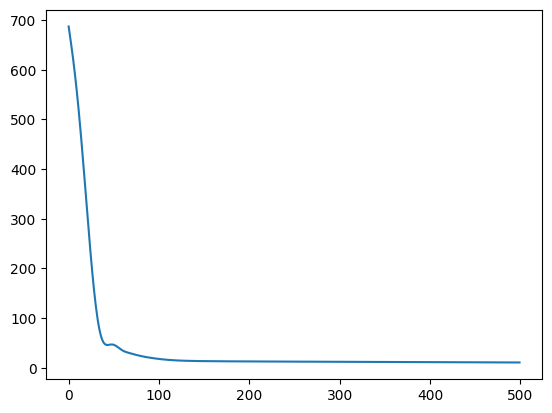

In [31]:
import matplotlib.pyplot as plt
plt.plot(ann_reg.losses)


In [ ]:
ann_reg.losses

[695.8425903320312,
 695.7023315429688,
 695.56201171875,
 695.4217529296875,
 695.2813720703125,
 695.1411743164062,
 695.0009765625,
 694.8607788085938,
 694.7205200195312,
 694.5804443359375,
 694.4402465820312,
 694.3001098632812,
 694.1600341796875,
 694.0199584960938,
 693.8799438476562,
 693.7398681640625,
 693.599853515625,
 693.4598388671875,
 693.3198852539062,
 693.179931640625,
 693.0400390625,
 692.900146484375,
 692.7601928710938,
 692.6204223632812,
 692.4805297851562,
 692.3407592773438,
 692.2009887695312,
 692.0611572265625,
 691.92138671875,
 691.7816772460938,
 691.6419677734375,
 691.5023193359375,
 691.3626098632812,
 691.2230224609375,
 691.0833129882812,
 690.9437255859375,
 690.8041381835938,
 690.66455078125,
 690.5250244140625,
 690.3854370117188,
 690.2459716796875,
 690.1063842773438,
 689.9668579101562,
 689.827392578125,
 689.68798828125,
 689.5485229492188,
 689.4089965820312,
 689.2695922851562,
 689.1302490234375,
 688.9907836914062,
 688.8514404296875

In [ ]:
(1/(462*461)) * np.sum((f_results["z"] - np.mean(f_results["z"]))**2)



np.float64(0.3853746173320788)

In [ ]:
z_hat = np.mean(f_results["z"])
z = f_results["z"]

$$
\frac{1}{n(n-1)}
$$

In [ ]:
np.std(z)

np.float64(13.328829603160523)

In [ ]:
n=462

np.sqrt((1 / ((n-1))) * np.sum((f_results["z"] - np.mean(f_results["z"]))**2))

np.float64(13.328829603160523)

In [ ]:
np.sum([(z_val - z_hat)**2 for z_val in z])

np.float64(82077.8567486208)

In [ ]:

np.sum()

TypeError: sum() missing 1 required positional argument: 'a'